In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("../data/processed/ecommerce_encoded.csv")

In [5]:
df.head()

,User_ID,Product_ID,Category,Price,Rating,Browsing_Time,Previous_Purchases,Cart_Addition,Purchase_Status,Age,Gender,Location,Discount_Applied,Total_Spending
0,100001,5033,2,1360,2,0.000000,0,0,0,56,1,3,0,0
1,100002,5038,3,4272,2,64.000000,0,0,0,46,0,3,0,0
2,100003,5266,5,3592,2,0.000000,0,0,0,32,1,5,0,0
3,100004,5120,1,966,2,2.666667,0,0,0,25,1,6,0,0
4,100005,5191,1,4926,2,627.500000,2,0,0,38,1,3,0,0


In [13]:
X = df[
[
"Price",
"Browsing_Time",
"Previous_Purchases",
"Discount_Applied",
"Age",
"Category",
"Total_Spending"
]
]

y = df["Rating"]

In [14]:
X_train, X_test, y_train, y_test = train_test_split(

X,

y,

test_size=0.20,

random_state=42

)

In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [15]:
joblib.dump(
    scaler,
    "../models/regression_scaler.pkl"
)

['../models/regression_scaler.pkl']

In [16]:
linear_model = LinearRegression()

linear_model.fit(
    X_train,
    y_train
)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
linear_predictions = linear_model.predict(X_test)

In [18]:
results = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": linear_predictions
})

results.head(10)

,Actual Rating,Predicted Rating
0,2,2.257803
1,4,3.399080
2,2,2.210078
3,2,2.398316
4,2,2.282718
5,2,2.135718
6,2,2.118967
7,2,2.271145
8,2,2.092443
9,2,2.171603


In [19]:
linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_mse = mean_squared_error(
    y_test,
    linear_predictions
)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")

print("MAE :", linear_mae)

print("MSE :", linear_mse)

print("RMSE :", linear_rmse)

print("R² :", linear_r2)

Linear Regression Results
MAE : 0.48897129901794095
MSE : 0.6197782069339322
RMSE : 0.7872599360655489
R² : 0.28445243876859705


In [20]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(
    X_train,
    y_train
)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [21]:
ridge_predictions = ridge_model.predict(X_test)

In [22]:
ridge_mae = mean_absolute_error(
    y_test,
    ridge_predictions
)

ridge_mse = mean_squared_error(
    y_test,
    ridge_predictions
)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(
    y_test,
    ridge_predictions
)

print("Ridge Regression Results")

print("MAE :", ridge_mae)

print("MSE :", ridge_mse)

print("RMSE :", ridge_rmse)

print("R² :", ridge_r2)

Ridge Regression Results
MAE : 0.4889709421119597
MSE : 0.6197788623386272
RMSE : 0.787260352322297
R² : 0.28445168208947236


In [23]:
comparison = pd.DataFrame({

"Model":[
"Linear Regression",
"Ridge Regression"
],

"MAE":[
linear_mae,
ridge_mae
],

"MSE":[
linear_mse,
ridge_mse
],

"RMSE":[
linear_rmse,
ridge_rmse
],

"R²":[
linear_r2,
ridge_r2
]

})

comparison

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.488971,0.619778,0.78726,0.284452
1,Ridge Regression,0.488971,0.619779,0.78726,0.284452


In [24]:
if ridge_r2 > linear_r2:

    best_model = ridge_model

    best_name = "Ridge Regression"

else:

    best_model = linear_model

    best_name = "Linear Regression"

print("Best Model :", best_name)

Best Model : Linear Regression


In [25]:
joblib.dump(

best_model,

"../models/best_regression_model.pkl"

)

['../models/best_regression_model.pkl']

In [26]:
loaded_model = joblib.load(
"../models/best_regression_model.pkl"
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [30]:
# Select the very first row safely using .iloc
sample = X_test.iloc[0].values.reshape(1, -1)

prediction = loaded_model.predict(sample)
print("Predicted Rating :", round(prediction[0], 2))


Predicted Rating : 2.26


In [29]:
print(type(X_test))

<class 'pandas.core.frame.DataFrame'>


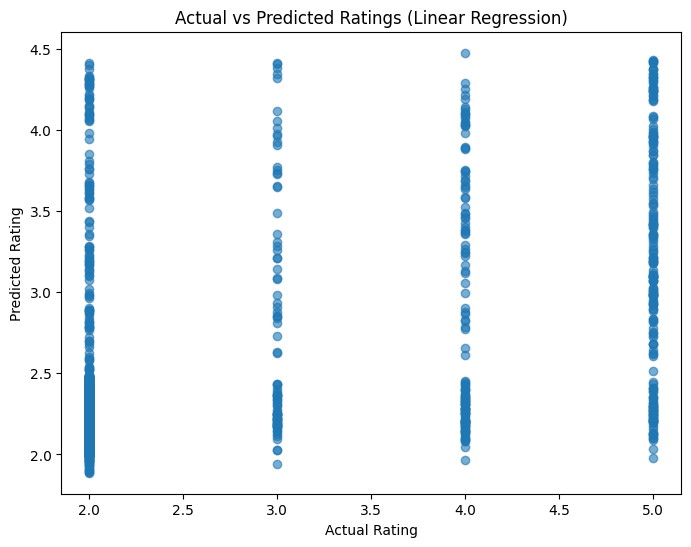

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    linear_predictions,
    alpha=0.6
)

plt.xlabel("Actual Rating")

plt.ylabel("Predicted Rating")

plt.title("Actual vs Predicted Ratings (Linear Regression)")

plt.show()

In [32]:
comparison.to_csv(

"../reports/regression_results.csv",

index=False

)

comparison

,Model,MAE,MSE,RMSE,R²
0,Linear Regression,0.488971,0.619778,0.78726,0.284452
1,Ridge Regression,0.488971,0.619779,0.78726,0.284452
